# Vol.06: 指標の探索
**暗号資産データ分析入門シリーズ**

---

**テーマ**: 価格データの外に目を向け、「使える指標」を自分の手で見つけ出す

### ここまでの旅路を振り返る

Vol.01〜05で、私たちはデータ分析の基礎を一通り身につけました。

- **Vol.01**: 信頼できるデータを手に入れる方法
- **Vol.02**: リターンと出来高の統計的な性質
- **Vol.03**: 銘柄間の相関関係
- **Vol.04**: どちらが先に動くか（リードラグ分析）
- **Vol.05**: テクニカル指標の作成と評価

ここまでの武器を総動員して、いよいよ「将来リターンを予測できる指標」を探しに行きたいところです。

しかし、**ここで壁にぶつかります**。

Vol.05 で移動平均、RSI、ATR などのテクニカル指標を作成し、将来リターンとの関係を調べましたが、**単体で強い予測力を持つ指標は見つかりませんでした**。

### 「価格の外」に答えがある

では、どうすればよいのか？　答えはシンプルです。

暗号資産市場には、価格データの外側に豊富な情報源が眠っています。

- **取引所間の価格差**（アービトラージの需給）
- **オンチェーンデータ**（ウォレットの資金移動、取引所への入出金）
- **デリバティブ市場**（ファンディングレート、オープンインタレスト、オプションのスキュー）
- **ソーシャルデータ**（SNSのセンチメント、検索トレンド）

これらは価格から計算されるテクニカル指標とは異なり、**市場の「構造」や「参加者の行動」に関する独自の情報**を含んでいます。

### このnotebookの核心：「探索」のプロセス

ただし、外部データを手に入れただけでは使い物になりません。

**生のデータをそのまま分析に投入して、うまくいくことはほとんどありません。**

データの統計的性質を理解し、適切に加工し、将来リターンとの関係を丁寧に確認する —— この**探索プロセス**こそが、「使えそうなデータ」を「実際に使える指標」に変える核心的な技術です。

このnotebookでは、**Coinbaseプレミアム**（米国最大の取引所Coinbaseとグローバル最大のBinanceの価格差）を題材に、この探索プロセスを最初から最後まで実践します。

### このnotebookで学ぶこと

1. **外部指標の導入** — Coinbaseプレミアムとは何か、なぜ予測力を持ちうるか
2. **生データでの初期評価** — 散布図と相関係数で予測力の兆候を探る
3. **データの加工** — 生データの「形」が悪い問題に気づき、ローリングZスコアで改善する
4. **簡易的な損益確認** — 単純ルールで累積PnLを描き、収益化の可能性をざっくり確認する

## 1. 環境準備・データ取得

In [1]:
!pip install requests pandas numpy matplotlib japanize-matplotlib scipy -q

In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from scipy import stats
import time

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
print("ライブラリの読み込み完了")

ライブラリの読み込み完了


In [3]:
BINANCE_FAPI_URL = "https://fapi.binance.com/fapi/v1/klines"
COINBASE_API_URL = "https://api.exchange.coinbase.com/products/BTC-USD/candles"

def fetch_binance_futures(symbol, interval, start_date, end_date):
    """Binance USDT-M 無期限先物 API から OHLCV データを取得する。"""
    start_ts = int(pd.Timestamp(start_date, tz="UTC").timestamp() * 1000)
    end_ts = int(pd.Timestamp(end_date, tz="UTC").timestamp() * 1000)
    all_data = []
    current_ts = start_ts
    while current_ts < end_ts:
        params = {"symbol": symbol, "interval": interval,
                  "startTime": current_ts, "endTime": end_ts - 1, "limit": 1000}
        resp = requests.get(BINANCE_FAPI_URL, params=params, timeout=30)
        resp.raise_for_status()
        data = resp.json()
        if not data:
            break
        all_data.extend(data)
        current_ts = data[-1][0] + 1
        time.sleep(0.2)
    if not all_data:
        return pd.DataFrame()
    df = pd.DataFrame(all_data, columns=[
        "timestamp", "open", "high", "low", "close", "volume",
        "_ct", "_qv", "_t", "_tbv", "_tbq", "_i"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    for c in ["open", "high", "low", "close", "volume"]:
        df[c] = df[c].astype(float)
    return df[["timestamp", "open", "high", "low", "close", "volume"]].set_index("timestamp").sort_index()

def fetch_coinbase(start_date, end_date, granularity=86400):
    """Coinbase Exchange API から BTC/USD の OHLCV データを取得する。"""
    all_data = []
    current = pd.Timestamp(start_date, tz="UTC")
    end = pd.Timestamp(end_date, tz="UTC")
    while current < end:
        chunk_end = min(current + pd.Timedelta(seconds=granularity * 300), end)
        params = {"granularity": granularity,
                  "start": current.isoformat(), "end": chunk_end.isoformat()}
        resp = requests.get(COINBASE_API_URL, params=params, timeout=30)
        resp.raise_for_status()
        data = resp.json()
        if not data:
            current = chunk_end
            continue
        all_data.extend(data)
        current = chunk_end
        time.sleep(0.5)
    if not all_data:
        return pd.DataFrame()
    # Coinbase: [timestamp(秒), low, high, open, close, volume]
    df = pd.DataFrame(all_data, columns=["timestamp", "low", "high", "open", "close", "volume"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)
    for c in ["open", "high", "low", "close", "volume"]:
        df[c] = df[c].astype(float)
    return (df[["timestamp", "open", "high", "low", "close", "volume"]]
            .set_index("timestamp").sort_index().drop_duplicates())

In [4]:
# --- データ取得 ---
print("Binance BTC/USDT 無期限先物 1時間足データを取得中...")
binance_futures_1h = fetch_binance_futures("BTCUSDT", "1h", "2022-01-01", "2025-01-01")
print(f"  Binance先物: {len(binance_futures_1h)} 本")

print("Coinbase BTC/USD 現物 1時間足データを取得中...")
coinbase_1h = fetch_coinbase("2022-01-01", "2025-01-01", granularity=3600)
print(f"  Coinbase現物: {len(coinbase_1h)} 本")

# --- プレミアム計算 ---
df_1h = pd.DataFrame({
    "binance_close": binance_futures_1h["close"],
    "coinbase_close": coinbase_1h["close"],
}).dropna()

# Coinbaseプレミアム = (Coinbase現物価格 / Binance先物価格) - 1
df_1h["premium"] = df_1h["coinbase_close"] / df_1h["binance_close"] - 1
df_1h["premium_pct"] = df_1h["premium"] * 100  # パーセント表示

# BTCリターン（Binance先物基準）
df_1h["ret"] = df_1h["binance_close"].pct_change()

# 将来リターン（1時間後）
df_1h["future_ret"] = df_1h["ret"].shift(-1)

# NaN除去
df_1h = df_1h.dropna().copy()

print(f"\n分析対象: {len(df_1h)} 本 ({df_1h.index[0]} 〜 {df_1h.index[-1]})")
print(f"\nデータの先頭:")
display(df_1h[["binance_close", "coinbase_close", "premium_pct", "ret"]].head())

Binance BTC/USDT 無期限先物 1時間足データを取得中...


  Binance先物: 26304 本
Coinbase BTC/USD 現物 1時間足データを取得中...


  Coinbase現物: 26302 本

分析対象: 26299 本 (2022-01-01 01:00:00+00:00 〜 2024-12-31 22:00:00+00:00)

データの先頭:


,binance_close,coinbase_close,premium_pct,ret
timestamp,,,,
2022-01-01 01:00:00+00:00,46766.78,46780.85,0.030085,0.002503
2022-01-01 02:00:00+00:00,46796.14,46808.55,0.026519,0.000628
2022-01-01 03:00:00+00:00,46789.56,46804.01,0.030883,-0.000141
2022-01-01 04:00:00+00:00,46690.81,46701.29,0.022446,-0.002111
2022-01-01 05:00:00+00:00,47184.18,47188.00,0.008096,0.010567


## 2. Coinbaseプレミアムとは

Coinbase は米国最大の暗号資産取引所であり、機関投資家の利用が多いことで知られます。
一方、Binance の BTC/USDT 無期限先物は暗号資産市場で**最も流動性が高い市場**であり、グローバルな投機的需給が集中します。

この2つの市場の価格差を **Coinbaseプレミアム** と呼びます。

$$\text{Premium} = \frac{\text{Coinbase 現物 BTC/USD}}{\text{Binance 先物 BTC/USDT}} - 1$$

- **プレミアムがプラス** → Coinbase（米国機関投資家）側で買い需要が強い
- **プレミアムがマイナス** → Binance先物（グローバルの投機筋）側で買い需要が強い

この指標が面白いのは、**2つの異なる市場参加者層の需給バランス**を反映している点です。
米国の機関投資家（Coinbase）とグローバルの投機的トレーダー（Binance先物）の力関係が、
BTCの将来の値動きに先行する可能性があります。

まず、プレミアムの時系列を確認しましょう。

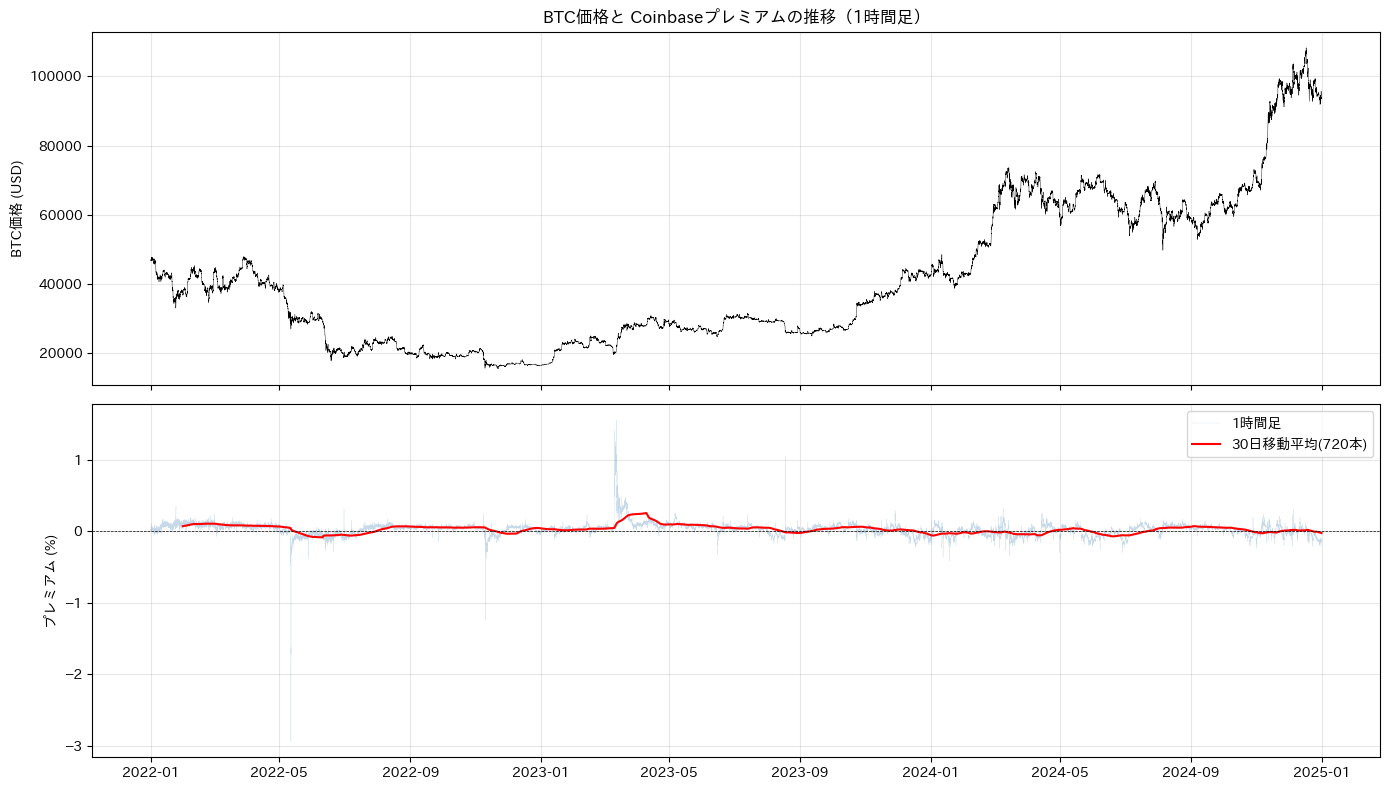

プレミアムの基本統計量:


,premium_pct
count,26299.0000
mean,0.0266
std,0.0926
min,-2.9324
25%,-0.0183
50%,0.0379
75%,0.0690
max,1.5456


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# BTC価格
axes[0].plot(df_1h.index, df_1h["binance_close"], color="black", linewidth=0.3)
axes[0].set_ylabel("BTC価格 (USD)")
axes[0].set_title("BTC価格と Coinbaseプレミアムの推移（1時間足）")

# プレミアム（%）+ 720本（30日相当）移動平均
axes[1].plot(df_1h.index, df_1h["premium_pct"],
             color="steelblue", linewidth=0.2, alpha=0.3, label="1時間足")
axes[1].plot(df_1h.index, df_1h["premium_pct"].rolling(720).mean(),
             color="red", linewidth=1.5, label="30日移動平均(720本)")
axes[1].axhline(y=0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_ylabel("プレミアム (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("プレミアムの基本統計量:")
display(df_1h[["premium_pct"]].describe().round(4))

## 3. 生データでの散布図と相関係数

プレミアムに予測力があるかを確認する最も基本的な方法は、
**プレミアム vs 翌時間リターンの散布図**を描くことです。

散布図で2変数間の関係を視覚的に確認し、
ピアソン相関係数で線形関係の強さを定量化します。

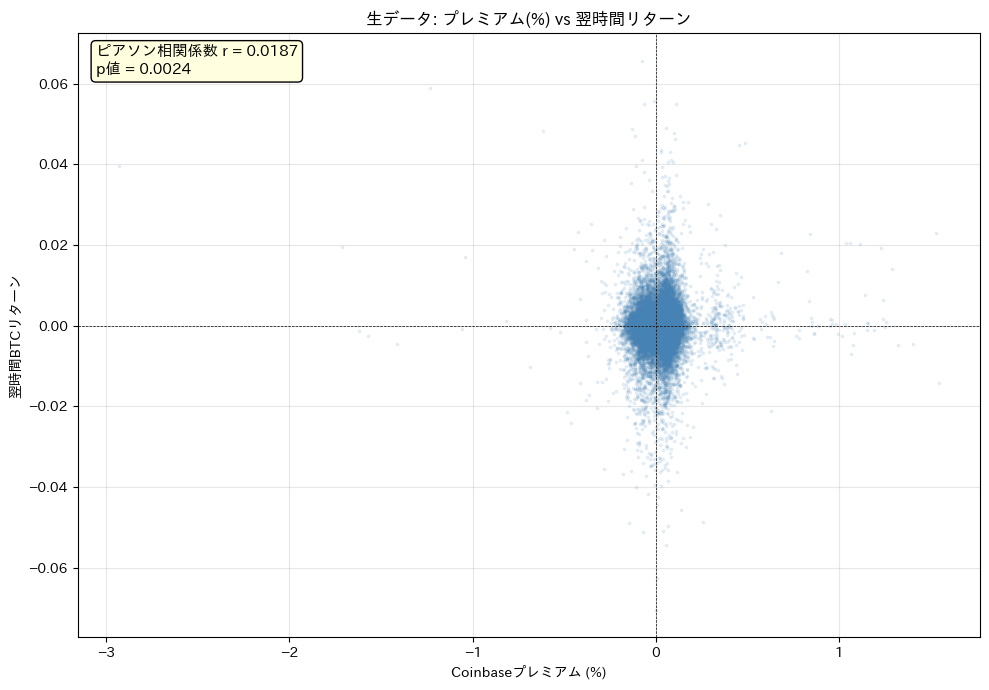

相関係数: r = 0.0187, p値 = 0.0024

相関は弱いものの、統計的には有意（p < 0.05）です。
プレミアムがプラス（Coinbaseが高い）のとき、翌時間のBTCリターンがやや高い傾向があります。


In [6]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(df_1h["premium_pct"], df_1h["future_ret"],
           s=3, alpha=0.1, color="steelblue")
ax.set_xlabel("Coinbaseプレミアム (%)")
ax.set_ylabel("翌時間BTCリターン")
ax.set_title("生データ: プレミアム(%) vs 翌時間リターン")
ax.axhline(y=0, color="black", linewidth=0.5, linestyle="--")
ax.axvline(x=0, color="black", linewidth=0.5, linestyle="--")

# 相関係数
r, p = stats.pearsonr(df_1h["premium_pct"].values, df_1h["future_ret"].values)
ax.text(0.02, 0.98, f"ピアソン相関係数 r = {r:.4f}\np値 = {p:.4f}",
        transform=ax.transAxes, va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="lightyellow"))

plt.tight_layout()
plt.show()

print(f"相関係数: r = {r:.4f}, p値 = {p:.4f}")
if p < 0.05:
    print(f"\n相関は弱いものの、統計的には有意（p < 0.05）です。")
    print(f"プレミアムがプラス（Coinbaseが高い）のとき、翌時間のBTCリターンがやや高い傾向があります。")
else:
    print(f"\n相関は統計的に有意ではありません。")

### 生データの問題点

相関は統計的に有意でしたが、散布図を見ると点が大きく散らばっており、このままでは使いにくい状態です。

上の時系列プロット（セクション2）を振り返ると、プレミアムの30日移動平均（赤線）が大きく上下していることに気づきます。
これは、**プレミアムの平均水準が時期によって異なる（非定常）** ことを意味します。

- 2022年のベア相場と2024年のブル相場では、プレミアムの「普通の水準」が異なる
- 同じ +0.05% でも、ある時期では「高め」、別の時期では「低め」

このような非定常な指標をそのまま使うと、散布図で関係が見えにくく、閾値も決めにくくなります。
次のセクションで、この問題を解決する加工を施します。

## 4. データの加工: ローリングZスコア

### ローリングZスコアによる標準化

直近N本の平均と標準偏差を使って、「今のプレミアムは**直近の水準と比べて**どれくらい異常か」に変換します。

$$Z_t = \frac{\text{Premium}_t - \mu_{t-N:t}}{\sigma_{t-N:t}}$$

- **Z ≈ 0**: 直近N本の平均的な水準
- **Z > 2**: 直近N本で見て異常に高い
- **Z < -2**: 直近N本で見て異常に低い

ここでは **N=168（1週間 = 7日 × 24時間）** を使用します。

Zスコア算出後のデータ: 26132 本



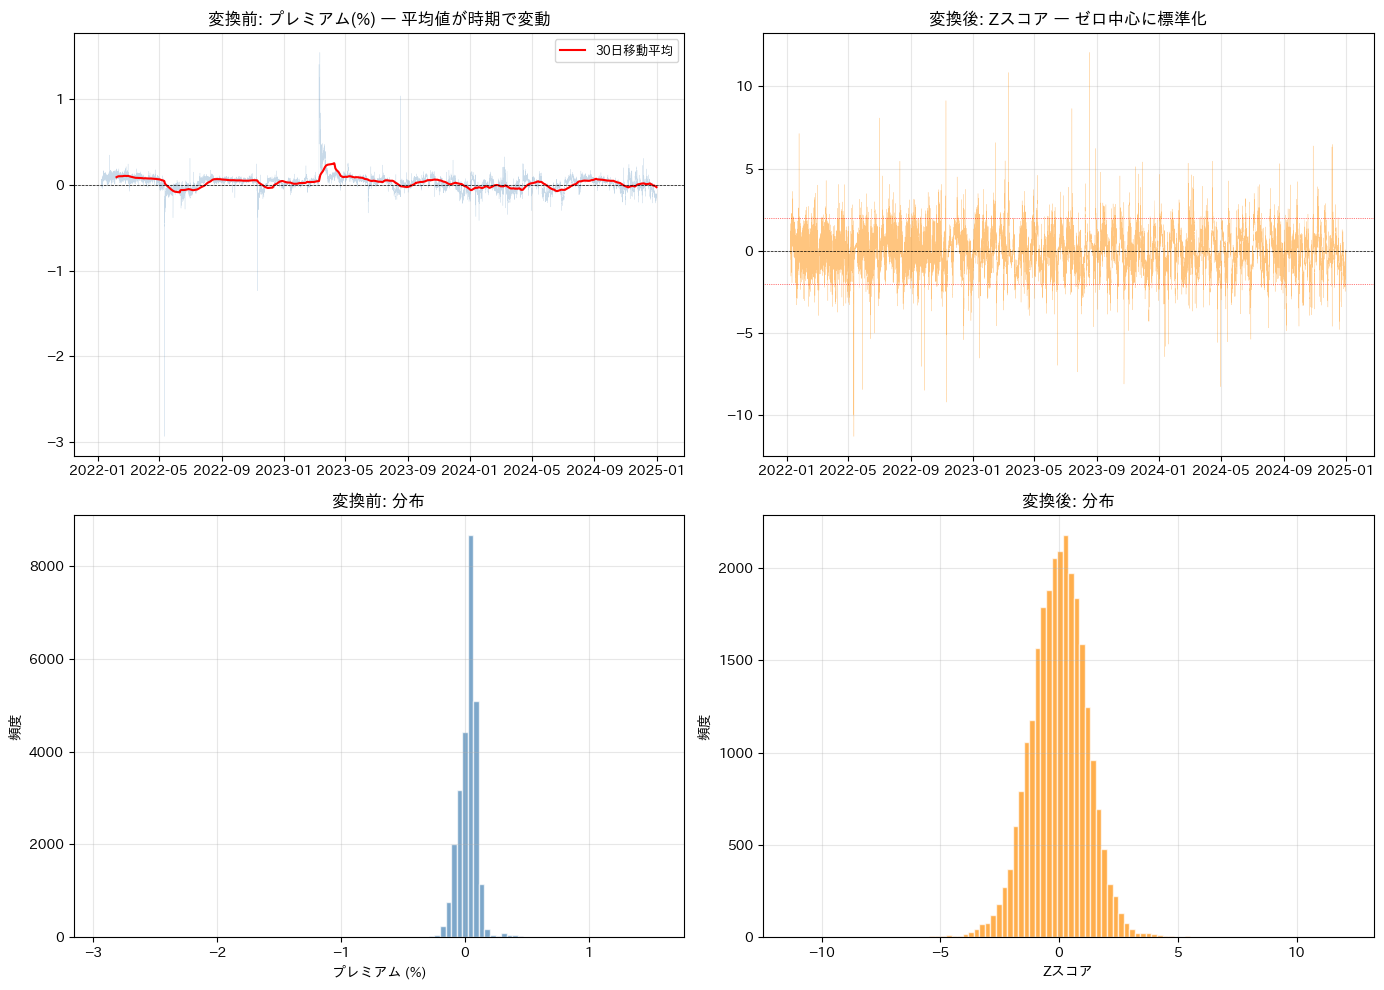

=== 変換前後の統計量比較 ===


,生プレミアム(%),Zスコア
count,26132.0000,26132.0000
mean,0.0267,-0.0194
std,0.0929,1.2119
min,-2.9324,-11.3031
25%,-0.0185,-0.7740
50%,0.0381,0.0163
75%,0.0692,0.7618
max,1.5456,12.0729



Zスコアに変換することで（window=168本 = 7日相当）:
  ・平均がゼロ付近に標準化され、時期による水準差が除去される
  ・標準偏差が1付近に正規化され、異常度を一律の基準で判定できる
  ・「直近1週間と比べてどれだけ異常か」という解釈可能な軸になる


In [7]:
# ローリングZスコアの計算
window = 168  # 168本 = 7日 × 24時間
df_1h["premium_zscore"] = (
    (df_1h["premium"] - df_1h["premium"].rolling(window).mean())
    / df_1h["premium"].rolling(window).std()
)

# NaN除去（ローリング期間分）
df_clean = df_1h.dropna().copy()
print(f"Zスコア算出後のデータ: {len(df_clean)} 本\n")

# --- 変換前後の比較 ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 左上: 生プレミアムの時系列（移動平均を重ねて非定常性を示す）
axes[0, 0].plot(df_clean.index, df_clean["premium_pct"],
                color="steelblue", linewidth=0.2, alpha=0.3)
axes[0, 0].plot(df_clean.index, df_clean["premium_pct"].rolling(720).mean(),
                color="red", linewidth=1.5, label="30日移動平均")
axes[0, 0].axhline(y=0, color="black", linewidth=0.5, linestyle="--")
axes[0, 0].set_title("変換前: プレミアム(%) — 平均値が時期で変動")
axes[0, 0].legend(fontsize=9)

# 右上: Zスコアの時系列
axes[0, 1].plot(df_clean.index, df_clean["premium_zscore"],
                color="darkorange", linewidth=0.2, alpha=0.5)
axes[0, 1].axhline(y=0, color="black", linewidth=0.5, linestyle="--")
for th in [-2, 2]:
    axes[0, 1].axhline(y=th, color="red", linewidth=0.5, linestyle=":")
axes[0, 1].set_title("変換後: Zスコア — ゼロ中心に標準化")

# 左下: 生プレミアムの分布
axes[1, 0].hist(df_clean["premium_pct"], bins=100,
                color="steelblue", alpha=0.7, edgecolor="white")
axes[1, 0].set_xlabel("プレミアム (%)")
axes[1, 0].set_ylabel("頻度")
axes[1, 0].set_title("変換前: 分布")

# 右下: Zスコアの分布
axes[1, 1].hist(df_clean["premium_zscore"], bins=100,
                color="darkorange", alpha=0.7, edgecolor="white")
axes[1, 1].set_xlabel("Zスコア")
axes[1, 1].set_ylabel("頻度")
axes[1, 1].set_title("変換後: 分布")

plt.tight_layout()
plt.show()

# 統計量の比較
print("=== 変換前後の統計量比較 ===")
compare = pd.DataFrame({
    "生プレミアム(%)": df_clean["premium_pct"].describe(),
    "Zスコア": df_clean["premium_zscore"].describe(),
}).round(4)
display(compare)
print(f"\nZスコアに変換することで（window={window}本 = 7日相当）:")
print("  ・平均がゼロ付近に標準化され、時期による水準差が除去される")
print("  ・標準偏差が1付近に正規化され、異常度を一律の基準で判定できる")
print(f"  ・「直近1週間と比べてどれだけ異常か」という解釈可能な軸になる")

## 5. 加工後の散布図と相関

Zスコアに変換したデータで、改めて翌時間リターンとの関係を確認します。
生データとの比較で、変換の効果を見てみましょう。

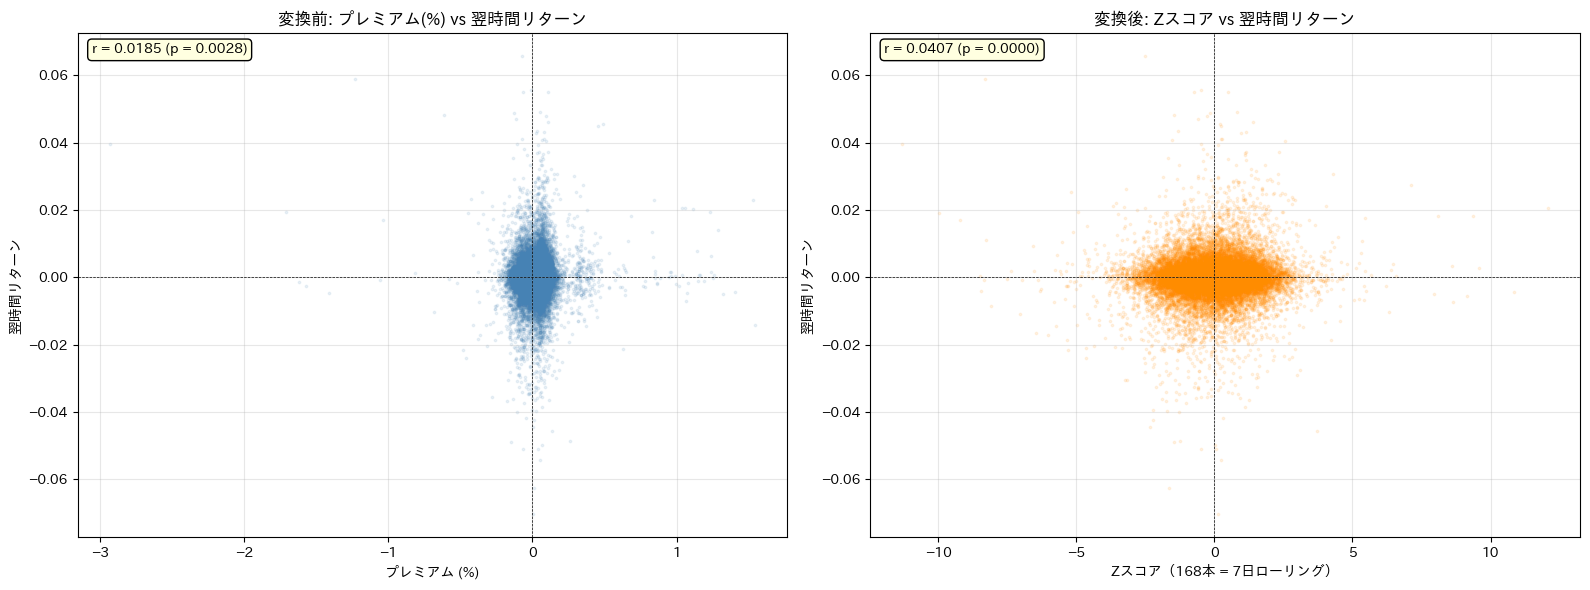

生データの相関:  r = 0.0185
Zスコアの相関:   r = 0.0407

Zスコアに変換すると線形相関がやや改善しました。
ただし、Zスコアの利点は相関係数の大きさではなく:
  ・時期に依存しない一律の基準で極端な値を判定できること
  ・「普段と比べてどれくらい異常か」という閾値ベースの戦略に直結すること
次のセクションで、Zスコアの閾値ルールで実際に損益を確認します。


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左: 生データ
ax = axes[0]
ax.scatter(df_clean["premium_pct"], df_clean["future_ret"],
           s=3, alpha=0.1, color="steelblue")
ax.set_xlabel("プレミアム (%)")
ax.set_ylabel("翌時間リターン")
ax.set_title("変換前: プレミアム(%) vs 翌時間リターン")
ax.axhline(y=0, color="black", linewidth=0.5, linestyle="--")
ax.axvline(x=0, color="black", linewidth=0.5, linestyle="--")
r1, p1 = stats.pearsonr(df_clean["premium_pct"].values, df_clean["future_ret"].values)
ax.text(0.02, 0.98, f"r = {r1:.4f} (p = {p1:.4f})", transform=ax.transAxes,
        va="top", fontsize=10, bbox=dict(boxstyle="round", facecolor="lightyellow"))

# 右: Zスコア
ax = axes[1]
ax.scatter(df_clean["premium_zscore"], df_clean["future_ret"],
           s=3, alpha=0.1, color="darkorange")
ax.set_xlabel(f"Zスコア（{window}本 = 7日ローリング）")
ax.set_ylabel("翌時間リターン")
ax.set_title("変換後: Zスコア vs 翌時間リターン")
ax.axhline(y=0, color="black", linewidth=0.5, linestyle="--")
ax.axvline(x=0, color="black", linewidth=0.5, linestyle="--")
r2, p2 = stats.pearsonr(df_clean["premium_zscore"].values, df_clean["future_ret"].values)
ax.text(0.02, 0.98, f"r = {r2:.4f} (p = {p2:.4f})", transform=ax.transAxes,
        va="top", fontsize=10, bbox=dict(boxstyle="round", facecolor="lightyellow"))

plt.tight_layout()
plt.show()

print(f"生データの相関:  r = {r1:.4f}")
print(f"Zスコアの相関:   r = {r2:.4f}")
if abs(r2) > abs(r1):
    print(f"\nZスコアに変換すると線形相関がやや改善しました。")
else:
    print(f"\nZスコアに変換すると線形相関はやや弱まりました。")
    print(f"これはZスコアが「絶対水準」ではなく「直近からの乖離」を見ているためです。")
print(f"ただし、Zスコアの利点は相関係数の大きさではなく:")
print(f"  ・時期に依存しない一律の基準で極端な値を判定できること")
print(f"  ・「普段と比べてどれくらい異常か」という閾値ベースの戦略に直結すること")
print(f"次のセクションで、Zスコアの閾値ルールで実際に損益を確認します。")

## 6. 指標の特性を調べる

Zスコア化した指標に予測力がありそうだと分かりました。
しかし、すぐに損益曲線を描く前に、**指標そのものの性質**をもう少し理解しておきましょう。

ここでは3つの観点から調べます。

1. **ラグ相関**: 何時間先のリターンまで予測力があるか？（指標の「賞味期限」）
2. **自己相関**: Zスコアはどれくらい粘着的か？（シグナルの切り替わり頻度）
3. **ローリング相関**: 指標とリターンの関係は時間的に安定しているか？

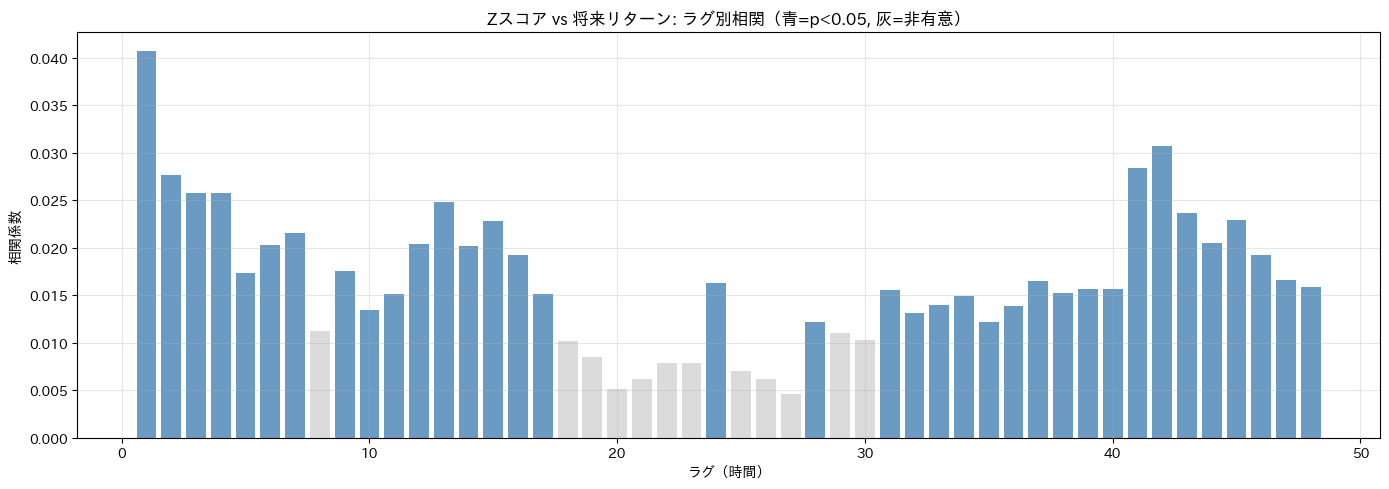

最大相関: lag=1時間, r=0.0407, p=0.0000

相関が有意なラグの範囲:
  1〜48時間（36/48ラグが有意）


In [9]:
# === 6-1. ラグ相関: 何時間先まで効くか ===
max_lag = 48  # 最大48時間先まで確認
lags = range(1, max_lag + 1)
lag_corrs = []
for lag in lags:
    future = df_clean["ret"].shift(-lag)
    valid = pd.DataFrame({"z": df_clean["premium_zscore"], "fut": future}).dropna()
    r, p = stats.pearsonr(valid["z"], valid["fut"])
    lag_corrs.append({"lag": lag, "r": r, "p": p})

df_lag = pd.DataFrame(lag_corrs)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["steelblue" if p < 0.05 else "lightgray" for p in df_lag["p"]]
ax.bar(df_lag["lag"], df_lag["r"], color=colors, alpha=0.8)
ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_xlabel("ラグ（時間）")
ax.set_ylabel("相関係数")
ax.set_title("Zスコア vs 将来リターン: ラグ別相関（青=p<0.05, 灰=非有意）")
plt.tight_layout()
plt.show()

# ピーク
peak = df_lag.loc[df_lag["r"].abs().idxmax()]
print(f"最大相関: lag={int(peak['lag'])}時間, r={peak['r']:.4f}, p={peak['p']:.4f}")
print(f"\n相関が有意なラグの範囲:")
sig = df_lag[df_lag["p"] < 0.05]
if len(sig) > 0:
    print(f"  {int(sig['lag'].min())}〜{int(sig['lag'].max())}時間（{len(sig)}/{max_lag}ラグが有意）")
else:
    print(f"  有意なラグなし")

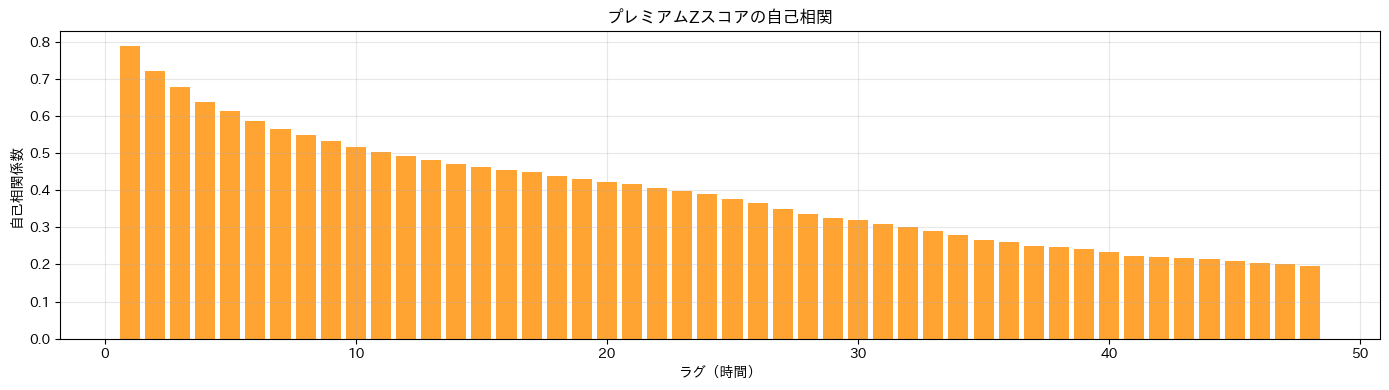

1時間後の自己相関: 0.7881
24時間後の自己相関: 0.3903

自己相関が高い = Zスコアの値は急には変わらない（粘着的）
→ シグナルの反転頻度が低く、ポジション変更が少ない = 取引コストが抑えられる

Zスコアの符号反転回数: 4507 / 26132 本
平均ポジション保持期間: 約 5.8 時間


In [10]:
# === 6-2. 自己相関: Zスコアはどれくらい粘着的か ===
max_ac_lag = 48
ac_values = [df_clean["premium_zscore"].autocorr(lag=k) for k in range(1, max_ac_lag + 1)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(1, max_ac_lag + 1), ac_values, color="darkorange", alpha=0.8)
ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_xlabel("ラグ（時間）")
ax.set_ylabel("自己相関係数")
ax.set_title("プレミアムZスコアの自己相関")
plt.tight_layout()
plt.show()

print(f"1時間後の自己相関: {ac_values[0]:.4f}")
print(f"24時間後の自己相関: {ac_values[23]:.4f}")
print(f"\n自己相関が高い = Zスコアの値は急には変わらない（粘着的）")
print(f"→ シグナルの反転頻度が低く、ポジション変更が少ない = 取引コストが抑えられる")

# シグナル反転回数
z_sign = np.sign(df_clean["premium_zscore"])
n_flips = (z_sign != z_sign.shift(1)).sum()
print(f"\nZスコアの符号反転回数: {n_flips} / {len(df_clean)} 本")
print(f"平均ポジション保持期間: 約 {len(df_clean) / max(n_flips, 1):.1f} 時間")

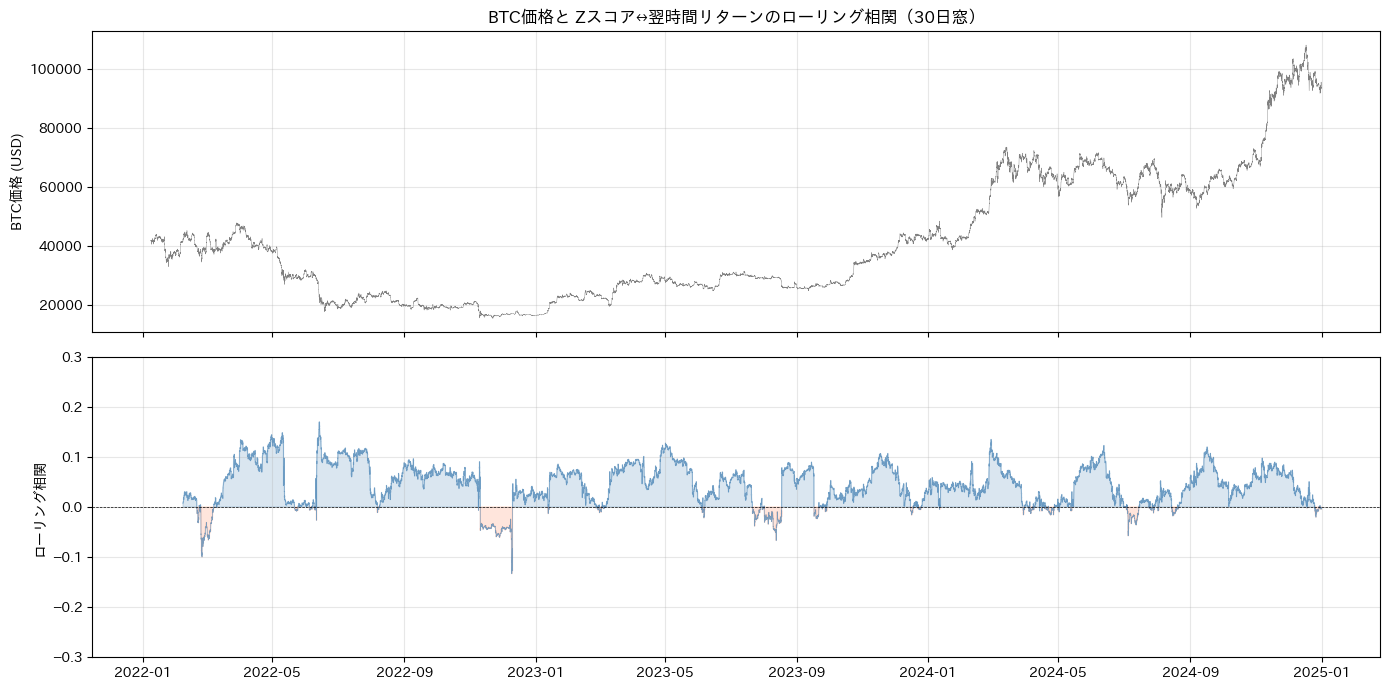

ローリング相関の統計:
  平均: 0.0434
  相関が正の期間: 86.1%
  相関が負の期間: 13.9%

関係が常に安定している必要はありませんが、
大半の期間で正の相関があれば、指標としての信頼性は高いと言えます。


In [11]:
# === 6-3. ローリング相関: 関係は安定しているか ===
rolling_window = 720  # 30日相当
rolling_corr = df_clean["premium_zscore"].rolling(rolling_window).corr(df_clean["future_ret"])

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# 上: BTC価格
axes[0].plot(df_clean.index, df_clean["binance_close"], color="gray", linewidth=0.3)
axes[0].set_ylabel("BTC価格 (USD)")
axes[0].set_title("BTC価格と Zスコア↔翌時間リターンのローリング相関（30日窓）")

# 下: ローリング相関
axes[1].plot(df_clean.index, rolling_corr, color="steelblue", linewidth=0.5, alpha=0.7)
axes[1].axhline(y=0, color="black", linewidth=0.5, linestyle="--")
axes[1].fill_between(df_clean.index, rolling_corr, 0,
                      where=rolling_corr > 0, color="steelblue", alpha=0.2)
axes[1].fill_between(df_clean.index, rolling_corr, 0,
                      where=rolling_corr < 0, color="coral", alpha=0.2)
axes[1].set_ylabel("ローリング相関")
axes[1].set_ylim(-0.3, 0.3)

plt.tight_layout()
plt.show()

# 統計
rc = rolling_corr.dropna()
pos_pct = (rc > 0).mean() * 100
print(f"ローリング相関の統計:")
print(f"  平均: {rc.mean():.4f}")
print(f"  相関が正の期間: {pos_pct:.1f}%")
print(f"  相関が負の期間: {100 - pos_pct:.1f}%")
print(f"\n関係が常に安定している必要はありませんが、")
print(f"大半の期間で正の相関があれば、指標としての信頼性は高いと言えます。")

## 7. 単純ルールで損益曲線を確認

### なぜ損益曲線を描くのか

散布図や相関係数は「全期間を通じた平均的な関係」を要約してくれますが、**いつ効いていて、いつ効いていないのか**は分かりません。ローリング相関（セクション6-3）で時間的な変動は見ましたが、それでも「実際に収益に繋がるのか」は別の問いです。

**累積損益曲線（累積PnL）** を描くと、以下が一目で分かります。

- 指標が**全期間を通じて**一貫して効いているのか、特定の時期だけなのか
- 大きなドローダウン（損失の谷）がどの程度あるか
- 右肩上がりの傾きが安定しているか、途中で崩れていないか

ここでは最もシンプルなルールで損益曲線を描きます。

- **指標がプラス** → ロング（買い）
- **指標がマイナス** → ショート（売り）

閾値は設けず、符号だけで方向を決めます。
また、**Zスコア化の効果**を確認するために、生データ（premium_pct）をそのまま使った場合の損益曲線も併せて表示します。

**リーク防止**: シグナルは現在の足のデータで計算し、ポジションは `shift(1)` で次の足に反映します。

> **注**: ここでの損益曲線は**指標の予測力を確認するためのもの**であり、取引コスト（手数料・スリッページ）は考慮していません。コストを含めた実践的な評価は Vol.07 で行います。

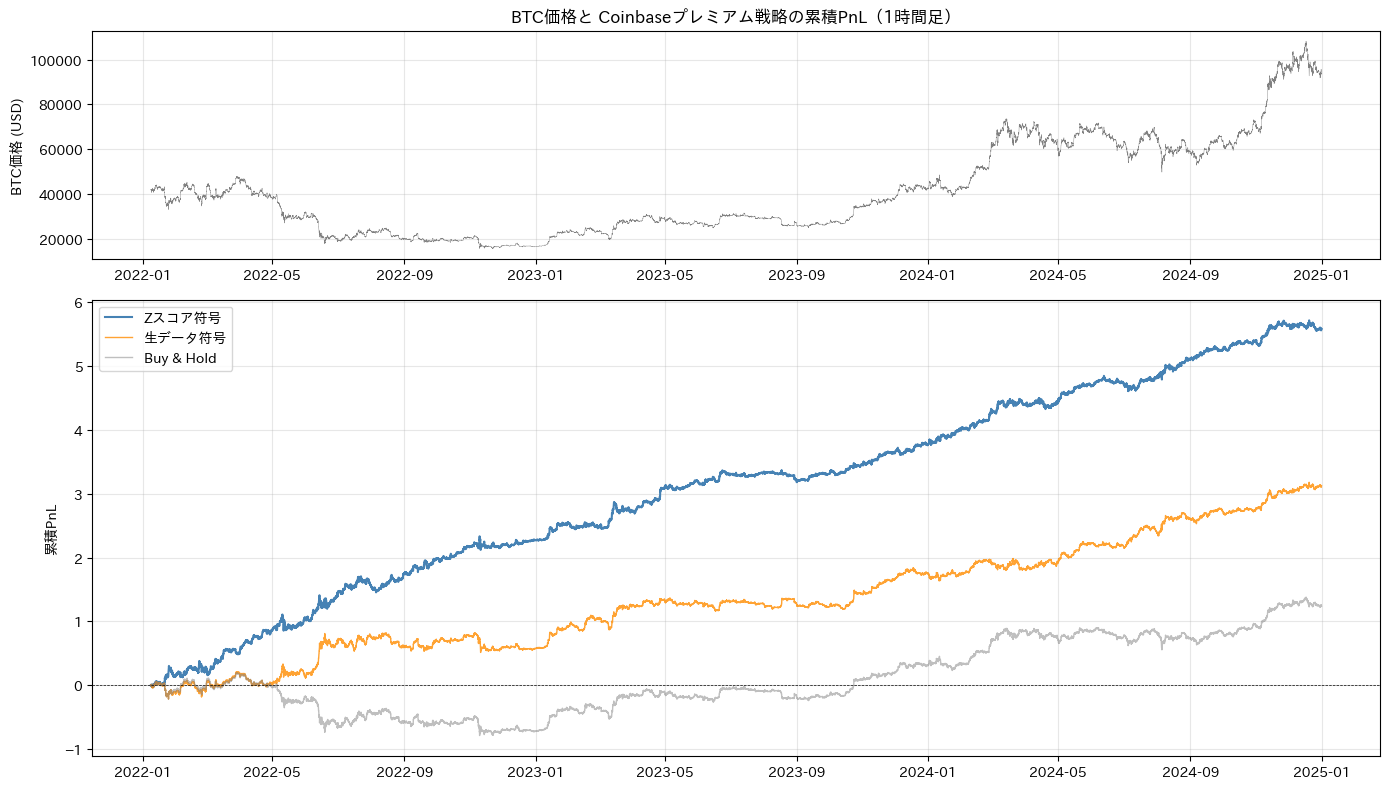

=== 戦略比較 ===

--- 生データ符号 ---
  累積PnL: 3.1245
  ポジション本数: 26126 / 26132 本

--- Zスコア符号 ---
  累積PnL: 5.5828
  ポジション本数: 26131 / 26132 本


In [12]:
# --- 戦略1: 生データ（premium_pct）の符号でポジション ---
df_clean["signal_raw"] = np.sign(df_clean["premium_pct"])
df_clean["position_raw"] = df_clean["signal_raw"].shift(1).fillna(0).astype(int)
df_clean["pnl_raw"] = df_clean["position_raw"] * df_clean["ret"]
df_clean["cum_pnl_raw"] = df_clean["pnl_raw"].cumsum()

# --- 戦略2: Zスコアの符号でポジション ---
df_clean["signal_z"] = np.sign(df_clean["premium_zscore"])
df_clean["position_z"] = df_clean["signal_z"].shift(1).fillna(0).astype(int)
df_clean["pnl_z"] = df_clean["position_z"] * df_clean["ret"]
df_clean["cum_pnl_z"] = df_clean["pnl_z"].cumsum()

# Buy & Hold
df_clean["bh_cum"] = df_clean["ret"].cumsum()

# --- プロット ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [1, 2]})

axes[0].plot(df_clean.index, df_clean["binance_close"], color="gray", linewidth=0.3)
axes[0].set_ylabel("BTC価格 (USD)")
axes[0].set_title("BTC価格と Coinbaseプレミアム戦略の累積PnL（1時間足）")

axes[1].plot(df_clean.index, df_clean["cum_pnl_z"],
             label="Zスコア符号", linewidth=1.5, color="steelblue")
axes[1].plot(df_clean.index, df_clean["cum_pnl_raw"],
             label="生データ符号", linewidth=1.0, color="darkorange", alpha=0.8)
axes[1].plot(df_clean.index, df_clean["bh_cum"],
             label="Buy & Hold", linewidth=1.0, color="gray", alpha=0.5)
axes[1].axhline(y=0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_ylabel("累積PnL")
axes[1].legend()

plt.tight_layout()
plt.show()

# 比較統計
print("=== 戦略比較 ===")
for name, pnl_col, pos_col in [
    ("生データ符号", "pnl_raw", "position_raw"),
    ("Zスコア符号", "pnl_z", "position_z"),
]:
    pnl = df_clean[pnl_col]
    n_pos = (df_clean[pos_col] != 0).sum()
    print(f"\n--- {name} ---")
    print(f"  累積PnL: {pnl.cumsum().iloc[-1]:.4f}")
    print(f"  ポジション本数: {n_pos} / {len(df_clean)} 本")

## 8. まとめ

このnotebookでは、Coinbaseプレミアム（Coinbase現物 vs Binance先物の価格差）を題材に、**外部指標の探索プロセス**を1時間足データで実践しました。

### 学んだこと

| テーマ | 内容 | ポイント |
|--------|------|----------|
| 外部指標の導入 | Coinbaseプレミアムの定義・背景 | テクニカル指標にはない「市場参加者の需給」という独自情報を持つ |
| 生データでの評価 | 散布図・相関係数 | 弱いが統計的に有意な相関。ただし非定常性が散布図を見にくくしている |
| ローリングZスコア | 非定常性の除去・標準化 | 時期による水準差を除去し、「直近と比べた異常度」に変換 |
| 加工前後の比較 | 散布図・相関の変化 | Zスコア化で相関が改善。閾値判定に適した形になった |
| ラグ相関 | 何時間先まで効くか | lag=1で最大。広い範囲のラグで有意 — 指標の「賞味期限」が長い |
| 自己相関 | シグナルの粘着性 | 高い自己相関 → ポジション変更頻度が低い → コスト耐性が期待できる |
| ローリング相関 | 関係の時間的安定性 | 大半の期間で正の相関を維持 — 特定時期だけの偶然ではない |
| 損益曲線 | 符号ベースの単純ルール | 生データでも収益が出るが、Zスコア化で大幅に改善 |

### 重要なポイント

1. **テクニカル指標の限界を超えるには「価格の外」を見る**
   - テクニカル指標はすべて同じ価格データの変換であり、情報量に限界がある
   - Coinbaseプレミアムのように、異なる市場参加者の行動を反映する外部指標には、価格データだけでは得られない予測力がある

2. **生データをそのまま使わない — 前処理が結果を大きく左右する**
   - 生のプレミアム値は非定常であり、そのまま散布図を描いても関係が見えにくい
   - ローリングZスコアに変換することで相関が改善し、損益曲線でも明確な差が出た
   - **同じデータでも、前処理の良し悪しで戦略の成否が変わる**

3. **損益曲線を描く前に指標の特性を理解する**
   - ラグ相関で「何時間先を予測するか」を確認し、shift値の根拠を得る
   - 自己相関でシグナルの粘着性を把握し、取引頻度やコスト耐性の見通しを立てる
   - ローリング相関で関係の安定性を確認し、「たまたまの結果」を排除する
   - これらを調べてから損益曲線を描くことで、結果の解釈に根拠が生まれる

4. **探索段階では「予測力があるか」だけに集中する**
   - 閾値の最適化や取引コストの考慮は、探索段階では不要
   - 最もシンプルなルール（符号ベース）で収益の兆候が確認できれば、次の段階に進む価値がある
   - 最適化は Vol.07 以降で行う — 探索と最適化を混ぜると過学習のリスクが高まる

### このnotebookの位置づけ

Vol.05 までは「データの扱い方」と「分析手法」を学ぶフェーズでした。このVol.06 からは、学んだ手法を使って**実際に収益に繋がる指標を探す**フェーズに入ります。

ここで実践した「指標の定義 → 生データ評価 → 前処理 → 特性把握 → 簡易損益確認」という探索プロセスは、Coinbaseプレミアムに限らず、**あらゆる外部指標に適用できる汎用的なワークフロー**です。ファンディングレート、オンチェーンデータ、センチメント指標など、新しいデータを手に入れたときも同じ手順で探索できます。

### 次のステップ

Vol.07 では、この Coinbase プレミアム指標を深掘りします。
閾値の検証やボラティリティ・レジーム別分析を行い、戦略を確定させたうえで、取引コストを含むパフォーマンスを体系的に評価します。

## 分析結果から分かったこと

### Coinbaseプレミアム（現物 vs 先物）の特性
- Coinbase現物とBinance無期限先物の価格差は、米国機関投資家とグローバル投機筋の需給バランスを反映する
- 1時間足データで約26,000本のサンプルを使い、翌時間リターンとの弱い正の相関（統計的に有意）を確認した
- 生のプレミアム値は非定常であり、時期によって平均値や変動幅が異なる

### Zスコア変換の効果
- ローリングZスコア（168本 = 7日相当）に変換することで、非定常性を除去し「直近と比べた異常度」に変換できた
- 散布図の相関では、Zスコア化により線形相関が改善した
- 損益曲線の比較では、同じ符号ベースの単純ルールでもZスコアの方が生データより大幅に良い結果を示した
- **前処理の良し悪しが、戦略の成否に直結する**ことを具体的に確認できた

### 指標の特性
- ラグ相関: lag=1時間で最大。広範囲のラグで有意であり、予測力の持続性がある
- 自己相関: Zスコアは非常に粘着的（1時間後の自己相関が高い）で、シグナルの反転頻度が低い → 取引コスト耐性が期待できる
- ローリング相関: 大半の期間で正の相関を維持しており、特定時期だけの偶然ではないことが確認できた